<a href="https://colab.research.google.com/github/shikhar11x/marvel-face-recognition-cnn/blob/main/Avengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -q tensorflow scikit-learn matplotlib seaborn pillow

import os
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0, VGG16
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [11]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ZIP_PATH = "/content/drive/MyDrive/archive.zip"

In [9]:
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/archive.zip"
EXTRACT_DIR = "/content/avengers_dataset"

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

RAW_DATA_DIR = os.path.join(EXTRACT_DIR, "cropped_images")
print("Classes found:", os.listdir(RAW_DATA_DIR))

CHARACTER_MAP = {
    "chris_evans": "Captain_America",
    "chris_hemsworth": "Thor",
    "mark_ruffalo": "Hulk",
    "robert_downey_jr": "Iron_Man",
    "scarlett_johansson": "Black_Widow",
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.
Classes found: ['chris_hemsworth', 'scarlett_johansson', 'mark_ruffalo', 'robert_downey_jr', 'chris_evans']


         Character  Image_Count
0  Captain_America           50
1             Thor           53
2             Hulk           66
3         Iron_Man           51
4      Black_Widow           54

Total images: 274


/tmp/ipykernel_3690/382295197.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x="Character", y="Image_Count", palette="viridis")


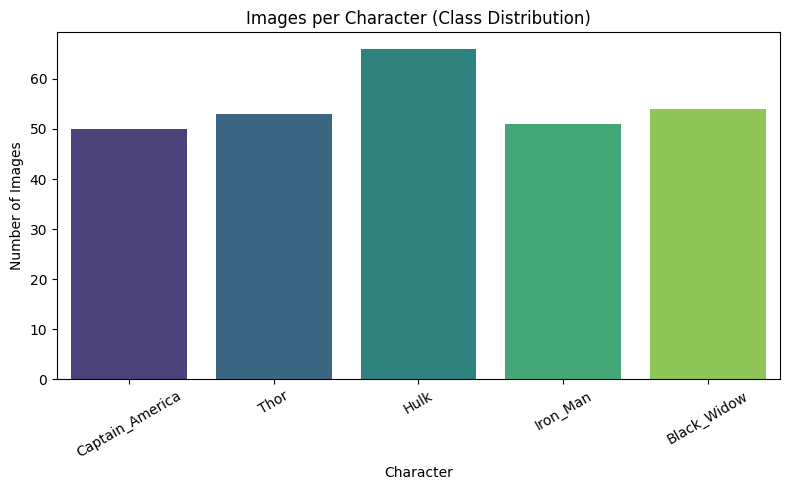

In [14]:
# ===================================================================
# CELL 3: DATASET EXPLORATION
# ===================================================================
class_counts = {}
for folder in sorted(os.listdir(RAW_DATA_DIR)):
    folder_path = os.path.join(RAW_DATA_DIR, folder)
    if os.path.isdir(folder_path):
        n_images = len([f for f in os.listdir(folder_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        char_name = CHARACTER_MAP.get(folder, folder)
        class_counts[char_name] = n_images

df_counts = pd.DataFrame(list(class_counts.items()), columns=["Character", "Image_Count"])
print(df_counts)
print("\nTotal images:", df_counts["Image_Count"].sum())

# Bar chart of class distribution (checks for class imbalance)
plt.figure(figsize=(8, 5))
sns.barplot(data=df_counts, x="Character", y="Image_Count", palette="viridis")
plt.title("Images per Character (Class Distribution)")
plt.xticks(rotation=30)
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()



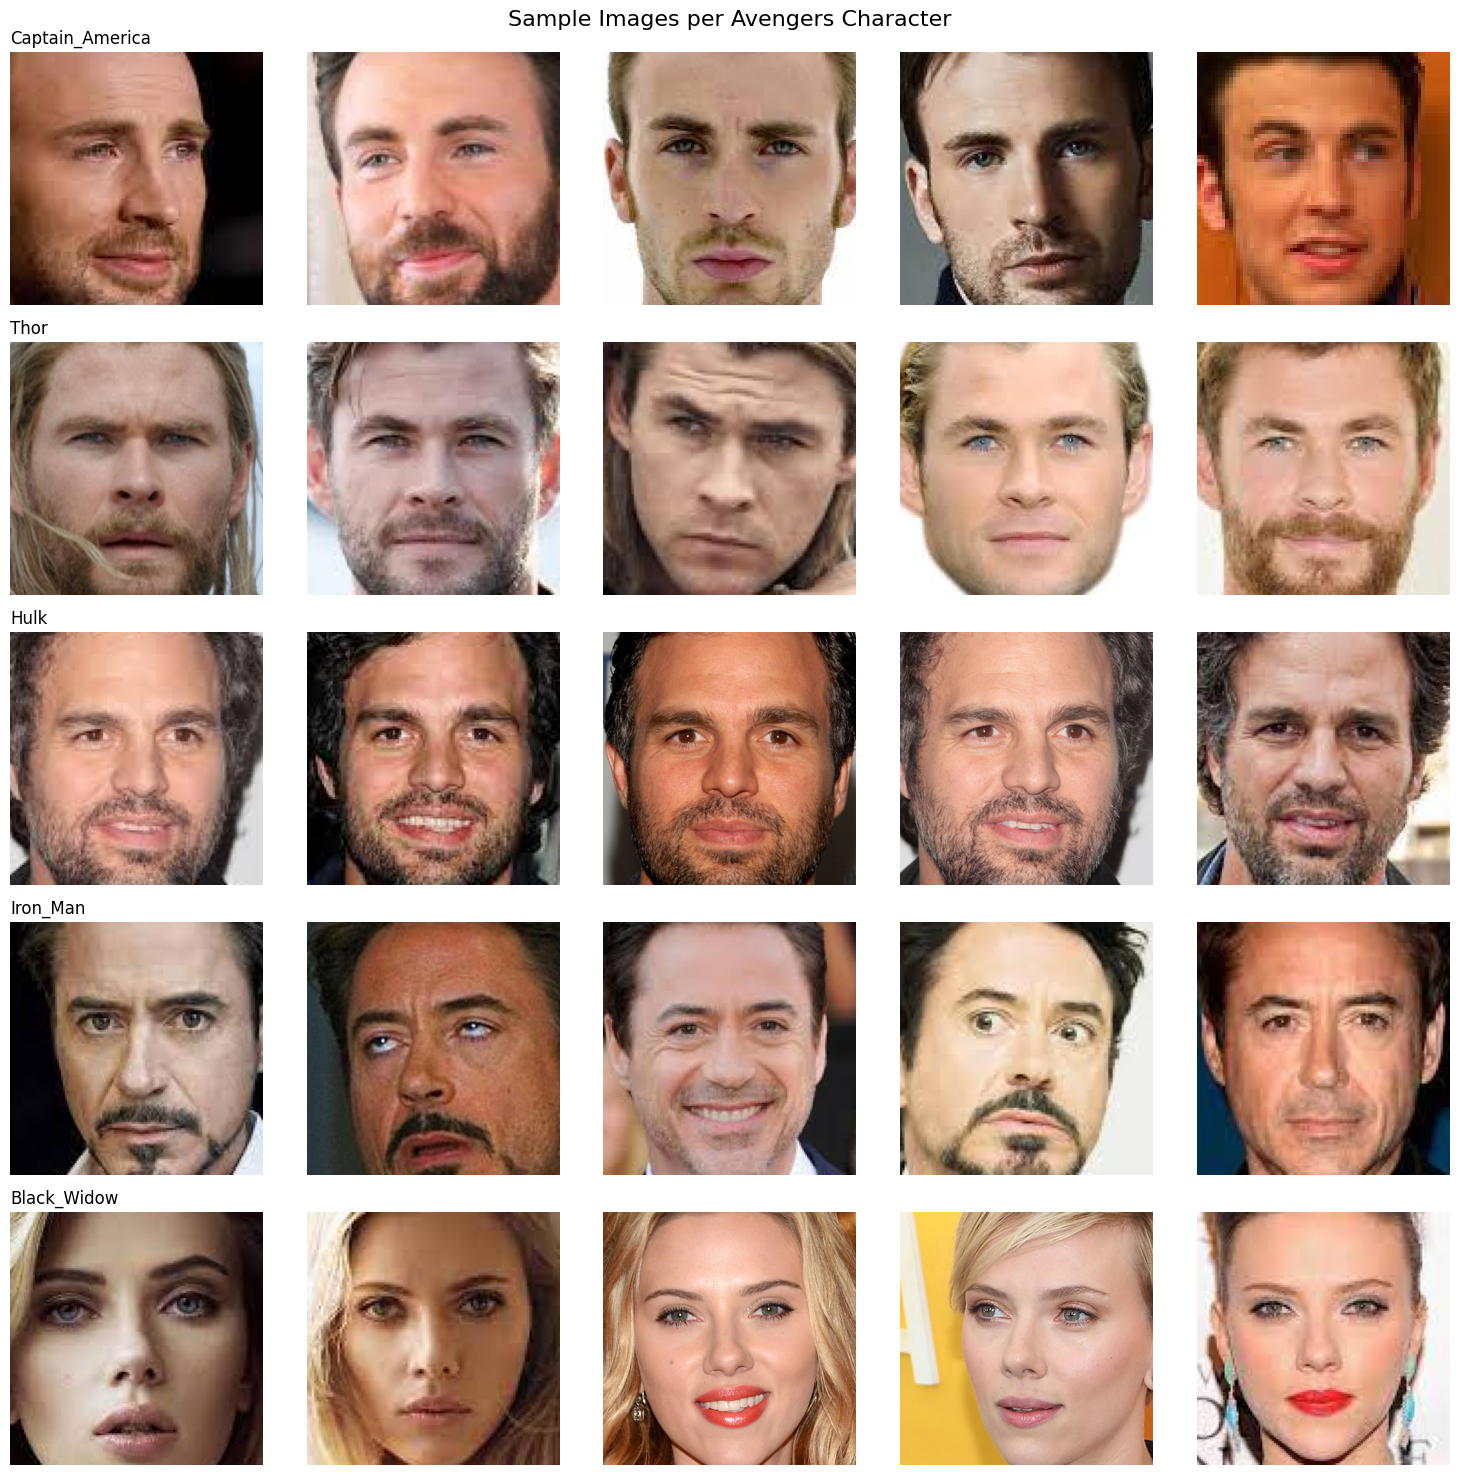

In [15]:
# Display sample images from each class
fig, axes = plt.subplots(len(CHARACTER_MAP), 5, figsize=(15, 3 * len(CHARACTER_MAP)))
for row, (folder, char_name) in enumerate(CHARACTER_MAP.items()):
    folder_path = os.path.join(RAW_DATA_DIR, folder)
    sample_files = os.listdir(folder_path)[:5]
    for col, fname in enumerate(sample_files):
        img = Image.open(os.path.join(folder_path, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(char_name, fontsize=12)
    axes[row, 0].set_title(char_name, fontsize=12, loc='left')
plt.suptitle("Sample Images per Avengers Character", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# ===================================================================
# CELL 4: DATA CLEANING — remove corrupt/unreadable images
# ===================================================================
def clean_dataset(data_dir):
    removed = 0
    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                img = Image.open(fpath)
                img.verify()  # checks file integrity
                # Re-open (verify() closes the file) and confirm it's RGB-convertible
                img2 = Image.open(fpath).convert("RGB")
                if img2.size[0] < 10 or img2.size[1] < 10:
                    os.remove(fpath)
                    removed += 1
            except (UnidentifiedImageError, IOError, SyntaxError):
                print(f"Removing corrupt file: {fpath}")
                os.remove(fpath)
                removed += 1
    print(f"\nCleaning complete. Removed {removed} corrupt/invalid files.")

clean_dataset(RAW_DATA_DIR)


Cleaning complete. Removed 0 corrupt/invalid files.


In [17]:
# ===================================================================
# CELL 5: STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ===================================================================
SPLIT_DIR = "/content/avengers_split"
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "val", "test"]:
    for char_name in CHARACTER_MAP.values():
        os.makedirs(os.path.join(SPLIT_DIR, split, char_name), exist_ok=True)

# 70% train, 15% val, 15% test — stratified per class
for folder, char_name in CHARACTER_MAP.items():
    folder_path = os.path.join(RAW_DATA_DIR, folder)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    train_files, temp_files = train_test_split(files, test_size=0.30, random_state=SEED)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=SEED)

    for fname in train_files:
        shutil.copy(os.path.join(folder_path, fname), os.path.join(SPLIT_DIR, "train", char_name, fname))
    for fname in val_files:
        shutil.copy(os.path.join(folder_path, fname), os.path.join(SPLIT_DIR, "val", char_name, fname))
    for fname in test_files:
        shutil.copy(os.path.join(folder_path, fname), os.path.join(SPLIT_DIR, "test", char_name, fname))

# Print resulting split sizes
for split in ["train", "val", "test"]:
    print(f"\n--- {split.upper()} ---")
    for char_name in CHARACTER_MAP.values():
        n = len(os.listdir(os.path.join(SPLIT_DIR, split, char_name)))
        print(f"  {char_name}: {n}")


--- TRAIN ---
  Captain_America: 35
  Thor: 37
  Hulk: 46
  Iron_Man: 35
  Black_Widow: 37

--- VAL ---
  Captain_America: 7
  Thor: 8
  Hulk: 10
  Iron_Man: 8
  Black_Widow: 8

--- TEST ---
  Captain_America: 8
  Thor: 8
  Hulk: 10
  Iron_Man: 8
  Black_Widow: 9


Found 190 images belonging to 5 classes.
Found 41 images belonging to 5 classes.
Found 43 images belonging to 5 classes.
Class indices: {'Black_Widow': 0, 'Captain_America': 1, 'Hulk': 2, 'Iron_Man': 3, 'Thor': 4}
Class weights (imbalance handling): {0: np.float64(1.027027027027027), 1: np.float64(1.0857142857142856), 2: np.float64(0.8260869565217391), 3: np.float64(1.0857142857142856), 4: np.float64(1.027027027027027)}


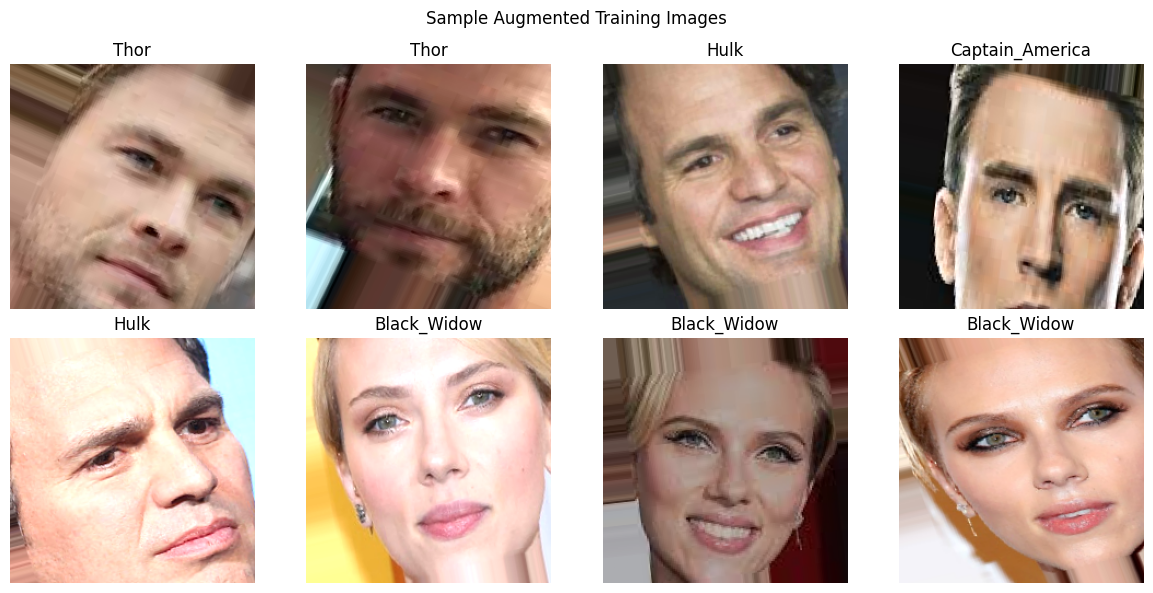

In [18]:
# ===================================================================
# CELL 6: PREPROCESSING & DATA AUGMENTATION
# ===================================================================
IMG_SIZE = (224, 224)   # standard input size for MobileNetV2/ResNet50/VGG16
BATCH_SIZE = 16          # small batch size suits our small dataset

# Training generator: heavy augmentation to compensate for small dataset size
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,             # normalize pixel values to [0,1]
    rotation_range=25,              # rotation augmentation
    zoom_range=0.20,                # zoom augmentation
    horizontal_flip=True,           # horizontal flip augmentation
    brightness_range=[0.7, 1.3],    # brightness adjustment
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    fill_mode='nearest'
)

# Validation & Test generators: only rescale, NO augmentation (must reflect real data)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print("Class indices:", train_generator.class_indices)

# Handle class imbalance: compute class weights so minority classes get more importance
labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights (imbalance handling):", class_weights)

# Visualize a batch of augmented images
sample_batch, sample_labels = next(train_generator)
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_batch[i])
    plt.title(CLASS_NAMES[np.argmax(sample_labels[i])])
    plt.axis('off')
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

In [19]:
# ===================================================================
# CELL 7: MODEL BUILDING — TRANSFER LEARNING
# ===================================================================
def build_model(base_name="MobileNetV2", num_classes=NUM_CLASSES, input_shape=(224, 224, 3)):
    """
    Builds a transfer-learning face-recognition model.
    base_name options: 'MobileNetV2', 'ResNet50', 'EfficientNetB0', 'VGG16'
    """
    if base_name == "MobileNetV2":
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_name == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_name == "EfficientNetB0":
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_name == "VGG16":
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported base_name")

    base_model.trainable = False  # freeze pretrained weights initially (feature extraction phase)

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)            # convert feature maps to feature vector
    x = BatchNormalization()(x)                # stabilizes & speeds up training
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)                        # regularization to prevent overfitting
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)   # final classification layer

    model = Model(inputs, outputs, name=f"AvengersFaceRecognition_{base_name}")
    return model, base_model

# Build the primary model — MobileNetV2 recommended for this small dataset size
BASE_MODEL_NAME = "MobileNetV2"
model, base_model = build_model(base_name=BASE_MODEL_NAME)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "AvengersFaceRecognition_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,605 (10.02 MB)

 Trainable params: 364,549 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [20]:
# ===================================================================
# CELL 8: CALLBACKS — Early Stopping, LR Scheduler, Checkpoint
# ===================================================================
os.makedirs("/content/models", exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/content/models/best_model_phase1.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks_list = [early_stop, lr_scheduler, checkpoint]

In [21]:
# ===================================================================
# CELL 9: PHASE 1 TRAINING — Feature extraction (base frozen)
# ===================================================================
EPOCHS_PHASE1 = 30

history_1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.2281 - loss: 2.1326
Epoch 1: val_accuracy improved from None to 0.29268, saving model to /content/models/best_model_phase1.keras

Epoch 1: finished saving model to /content/models/best_model_phase1.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.2789 - loss: 1.9945 - val_accuracy: 0.2927 - val_loss: 1.6298 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5014 - loss: 1.3016
Epoch 2: val_accuracy improved from 0.29268 to 0.41463, saving model to /content/models/best_model_phase1.keras

Epoch 2: finished saving model to /content/models/best_model_phase1.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4737 - loss: 1.3712 - val_accuracy: 0.4146 - val_loss: 1.4398 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.5234 - loss: 1.2222
Epoch 3: val_accuracy improved from 0.41463 to 0.51220, saving model to /content/models/best_mod

In [22]:
# ===================================================================
# CELL 10: PHASE 2 TRAINING — FINE-TUNING
# ===================================================================
base_model.trainable = True

# Freeze the earliest layers (generic edge/texture features), fine-tune only the top layers
FINE_TUNE_AT = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with a much smaller learning rate for gentle fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_finetune = ModelCheckpoint(
    filepath="/content/models/best_model_finetuned.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

EPOCHS_PHASE2 = 20

history_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler, checkpoint_finetune]
)

# Combine both training histories for unified plotting
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

full_history = merge_histories(history_1, history_2)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5018 - loss: 1.3796
Epoch 1: val_accuracy improved from None to 0.73171, saving model to /content/models/best_model_finetuned.keras

Epoch 1: finished saving model to /content/models/best_model_finetuned.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5474 - loss: 1.3046 - val_accuracy: 0.7317 - val_loss: 0.7161 - learning_rate: 1.0000e-05
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5621 - loss: 1.2058
Epoch 2: val_accuracy did not improve from 0.73171
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5789 - loss: 1.1428 - val_accuracy: 0.7317 - val_loss: 0.7515 - learning_rate: 1.0000e-05
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6024 - loss: 1.1471
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.73171
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6474 - loss: 1.0471 - val_accuracy: 0.7317 

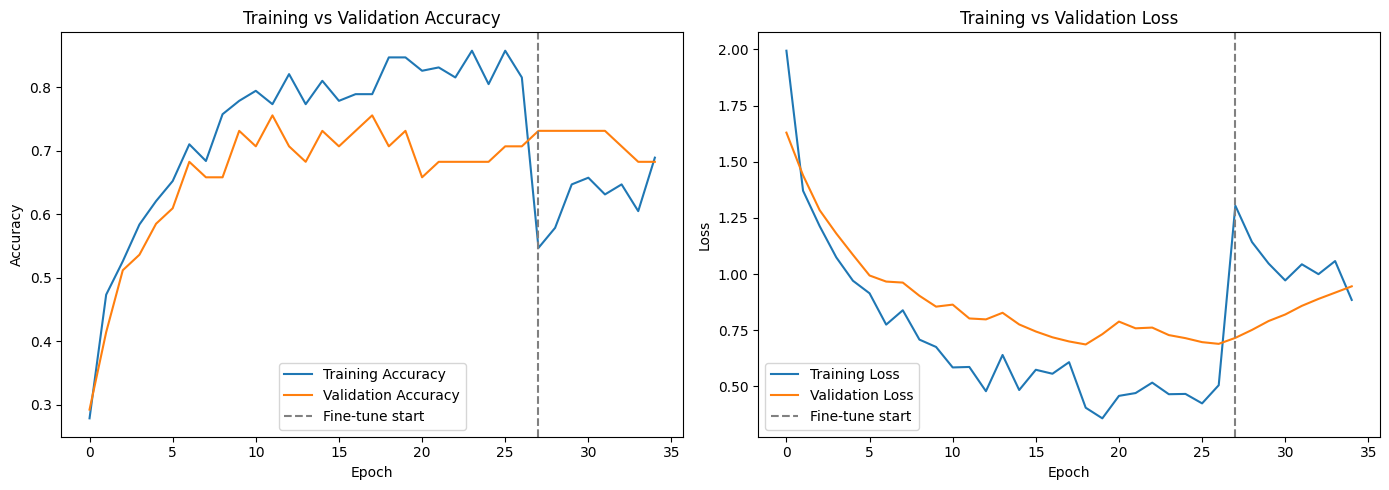

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 0.7907 - loss: 0.6675

Final Test Accuracy: 79.07%
Final Test Loss: 0.6675
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


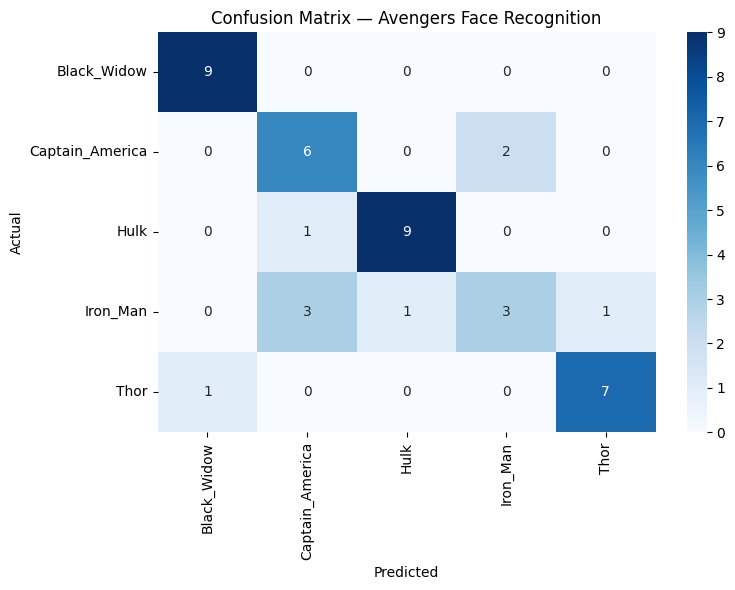

Classification Report:

                 precision    recall  f1-score   support

    Black_Widow      0.900     1.000     0.947         9
Captain_America      0.600     0.750     0.667         8
           Hulk      0.900     0.900     0.900        10
       Iron_Man      0.600     0.375     0.462         8
           Thor      0.875     0.875     0.875         8

       accuracy                          0.791        43
      macro avg      0.775     0.780     0.770        43
   weighted avg      0.784     0.791     0.780        43



In [23]:
# ===================================================================
# CELL 11: EVALUATION
# ===================================================================
# --- Accuracy & Loss curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(full_history['accuracy'], label='Training Accuracy')
axes[0].plot(full_history['val_accuracy'], label='Validation Accuracy')
axes[0].axvline(x=len(history_1.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(full_history['loss'], label='Training Loss')
axes[1].plot(full_history['val_loss'], label='Validation Loss')
axes[1].axvline(x=len(history_1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Test set evaluation ---
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

# --- Confusion Matrix ---
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Avengers Face Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- Classification Report ---
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3)
print("Classification Report:\n")
print(report)

In [ ]:
# ===================================================================
# CELL 12: COMPARE MULTIPLE PRETRAINED BACKBONES (OPTIONAL)
# ===================================================================
def quick_train_and_eval(base_name, epochs=10):
    m, bm = build_model(base_name=base_name)
    m.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_generator, validation_data=val_generator, epochs=epochs,
              class_weight=class_weights, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)])
    val_acc = max(h.history['val_accuracy'])
    print(f"{base_name}: best val_accuracy = {val_acc:.4f}")
    return base_name, val_acc

results = []
for backbone in ["MobileNetV2", "ResNet50", "EfficientNetB0", "VGG16"]:
    train_generator.reset() if hasattr(train_generator, 'reset') else None
    results.append(quick_train_and_eval(backbone, epochs=10))

results_df = pd.DataFrame(results, columns=["Model", "Val_Accuracy"]).sort_values("Val_Accuracy", ascending=False)
print("\n--- Backbone Comparison ---")
print(results_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="Model", y="Val_Accuracy", palette="mako")
plt.title("Backbone Comparison — Validation Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nBest performing backbone: {results_df.iloc[0]['Model']}")

MobileNetV2: best val_accuracy = 0.6829
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50: best val_accuracy = 0.2439
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0: best val_accuracy = 0.2195
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# ===================================================================
# CELL 13: SAVE MODEL
# ===================================================================
FINAL_MODEL_PATH_KERAS = "/content/models/avengers_face_recognition_final.keras"
FINAL_MODEL_PATH_H5 = "/content/models/avengers_face_recognition_final.h5"

model.save(FINAL_MODEL_PATH_KERAS)
model.save(FINAL_MODEL_PATH_H5)

# Also save the class label mapping for future inference (very important!)
import json
with open("/content/models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

# Optional: copy to Google Drive for permanent storage
DRIVE_SAVE_DIR = "/content/drive/MyDrive/avengers_face_recognition_model"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
shutil.copy(FINAL_MODEL_PATH_KERAS, DRIVE_SAVE_DIR)
shutil.copy(FINAL_MODEL_PATH_H5, DRIVE_SAVE_DIR)
shutil.copy("/content/models/class_indices.json", DRIVE_SAVE_DIR)

print("Model saved successfully at:", DRIVE_SAVE_DIR)

In [ ]:
# ===================================================================
# CELL 14: LOAD SAVED MODEL AND TEST
# ===================================================================
loaded_model = load_model(FINAL_MODEL_PATH_KERAS)

with open("/content/models/class_indices.json", "r") as f:
    class_indices = json.load(f)
idx_to_class = {v: k for k, v in class_indices.items()}

# Sanity check: re-evaluate on test set with the reloaded model
test_generator.reset()
loss, acc = loaded_model.evaluate(test_generator)
print(f"Reloaded model — Test Accuracy: {acc*100:.2f}%, Test Loss: {loss:.4f}")

In [ ]:
# ===================================================================
# CELL 15: PREDICTION SYSTEM — Upload an image, get character + confidence
# ===================================================================
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image

def predict_avenger_face(model, idx_to_class, img_size=(224, 224)):
    """
    Prompts the user to upload an image in Colab, runs prediction,
    and displays the image with the predicted character name and confidence.
    """
    uploaded = files.upload()  # opens a file picker in Colab

    for fname in uploaded.keys():
        img = Image.open(fname).convert("RGB")
        img_resized = img.resize(img_size)

        # Preprocess exactly like training data
        img_array = keras_image.img_to_array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        preds = model.predict(img_array)[0]
        pred_idx = np.argmax(preds)
        pred_class = idx_to_class[pred_idx]
        confidence = preds[pred_idx] * 100

        # Display result
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Character: {pred_class}\nConfidence: {confidence:.2f}%", fontsize=13)
        plt.show()

        print(f"Character: {pred_class}")
        print(f"Confidence: {confidence:.2f}%")

        # Show full probability breakdown across all classes
        print("\nFull prediction breakdown:")
        for i, prob in enumerate(preds):
            print(f"  {idx_to_class[i]}: {prob*100:.2f}%")

# Run the prediction system:
predict_avenger_face(loaded_model, idx_to_class)